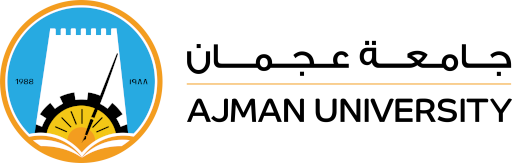

<p>
College: Engineering and Information Technology<br>
Department: Information Technology<br>
Major: artificial intelligence<br>
Academic Semester: Spring 2025-2026<br>
Course: DAT405 Machine Learning<br>
Course Instructor: Dr. Mahmoud AlShboul<br>
</p></center>

# DAT405 Machine Learning Course Project
## Predicting Insurance Claim Risk Using Machine Learning

### Abstract
This notebook builds a full machine learning pipeline to predict whether a driver will file an insurance claim using the Porto Seguro dataset from Kaggle. We start by exploring and cleaning the data, then prepare it through preprocessing and feature engineering to make it suitable for modeling. After that, we train different classification models, including Logistic Regression, Random Forest, and XGBoost. We evaluate their performance using metrics like accuracy, precision, recall, F1-score, and ROC-AUC. The results show that tree-based ensemble models, especially Random Forest and XGBoost, perform better than Logistic Regression for this problem.

---
**Team Members:**
- Member 1: [Rawan Riyadh 202410576] EDA
- Member 1: [Bibi Ekhkla Hashimi 202411435] Data Loading, Preprocessing
- Member 3: [Rawdha Tareq 202411209]  Feature Engineering
- Member 4: [Shahd Abdullah Abdo 202411824] Model development, Evaluation and Interpretation

Team Leader Student ID (used as random seed):202410576

---
## Section 1: Imports and Setup

We begin by importing all necessary libraries for data processing, visualization, and machine learning. We also set global configuration values such as the random seed and sample size.

In [ ]:
# standard library
import warnings
warnings.filterwarnings('ignore')

# data handling
import numpy as np
import pandas as pd

# visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# the three models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    RocCurveDisplay, ConfusionMatrixDisplay, classification_report
)

# mbalance handling
from imblearn.over_sampling import SMOTE

# the student ID of the team leader as the seed
SEED = 202410576
SAMPLE_SIZE = 100_000
np.random.seed(SEED)

print('All libraries loaded successfully.')
print(f'Random seed (202410576): {SEED}')
print(f'Sample size: {SAMPLE_SIZE:,}')

All libraries loaded successfully.
Random seed (202410576): 202410576
Sample size: 100,000


---
## Section 2: Dataset Description

The dataset comes from the [Porto Seguro Safe Driver Prediction](https://www.kaggle.com/competitions/porto-seguro-safe-driver-prediction) Kaggle competition.

The Porto Seguro dataset contains ~595k samples (we use 100k), 57 mixed features, and a binary target, with special suffixes indicating feature types and missing values encoded as -1.


In [ ]:

# Load the dataset.

df_full = pd.read_csv('train.csv')   # Full dataset
print(f'Full dataset shape: {df_full.shape}')

# Random sample of 100k rows using 202410576 as seed
df = df_full.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
print(f'Sampled dataset shape: {df.shape}')
df.head()

Full dataset shape: (118901, 59)
Sampled dataset shape: (100000, 59)


,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,159506,0,0,1,3,0,0,0,1,0,...,7.0,1.0,3.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0
1,152500,0,5,1,7,1,0,0,0,1,...,5.0,2.0,6.0,8.0,0.0,1.0,0.0,0.0,0.0,1.0
2,70223,0,1,1,2,1,0,0,0,1,...,1.0,1.0,0.0,4.0,1.0,1.0,1.0,0.0,0.0,0.0
3,217404,0,4,1,2,1,0,0,1,0,...,4.0,0.0,5.0,3.0,0.0,1.0,0.0,0.0,1.0,0.0
4,79220,0,1,2,5,1,0,0,1,0,...,12.0,3.0,5.0,4.0,0.0,1.0,1.0,0.0,1.0,0.0


---
## Section 3: Exploratory Data Analysis (EDA)

EDA helps us understand the structure of the data before modelling. We will:
1. Inspect shape, dtypes, and basic statistics
2. Analyse the target class balance
3. Detect and visualise missing values (encoded as -1)
4. Examine feature distributions
5. Analyse correlations

### 3.1 Dataset Structure

In [ ]:
# Basic info: dtypes, non-null counts
print('Dataset Info: ')
df.info(verbose=True, show_counts=True)
print()
print('Shape: ')
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')

Dataset Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              100000 non-null  int64  
 1   target          100000 non-null  int64  
 2   ps_ind_01       100000 non-null  int64  
 3   ps_ind_02_cat   100000 non-null  int64  
 4   ps_ind_03       100000 non-null  int64  
 5   ps_ind_04_cat   100000 non-null  int64  
 6   ps_ind_05_cat   100000 non-null  int64  
 7   ps_ind_06_bin   100000 non-null  int64  
 8   ps_ind_07_bin   100000 non-null  int64  
 9   ps_ind_08_bin   100000 non-null  int64  
 10  ps_ind_09_bin   100000 non-null  int64  
 11  ps_ind_10_bin   100000 non-null  int64  
 12  ps_ind_11_bin   100000 non-null  int64  
 13  ps_ind_12_bin   100000 non-null  int64  
 14  ps_ind_13_bin   100000 non-null  int64  
 15  ps_ind_14       100000 non-null  int64  
 16  ps_ind_15       100000 non-null  int64  
 

In [ ]:
# Descriptive statistics for all numeric columns
print('Descriptive Statistics:')
df.describe().T.round(3)

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
id,100000.0,148775.110,85819.045,7.000,74444.750,148875.500,223099.500,297340.000
target,100000.0,0.037,0.189,0.000,0.000,0.000,0.000,1.000
ps_ind_01,100000.0,1.904,1.985,0.000,0.000,1.000,3.000,7.000
ps_ind_02_cat,100000.0,1.357,0.663,-1.000,1.000,1.000,2.000,4.000
ps_ind_03,100000.0,4.427,2.700,0.000,2.000,4.000,6.000,11.000
ps_ind_04_cat,100000.0,0.416,0.493,-1.000,0.000,0.000,1.000,1.000
ps_ind_05_cat,100000.0,0.401,1.340,-1.000,0.000,0.000,0.000,6.000
ps_ind_06_bin,100000.0,0.392,0.488,0.000,0.000,0.000,1.000,1.000
ps_ind_07_bin,100000.0,0.256,0.436,0.000,0.000,0.000,1.000,1.000
ps_ind_08_bin,100000.0,0.164,0.370,0.000,0.000,0.000,0.000,1.000


The describe() output shows that missing values are represented by -1 and will be handled during preprocessing.

### 3.2 Target Variable — Class Imbalance

Target distribution:
        Count  Percentage (%)
target                       
0       96285           96.28
1        3715            3.72


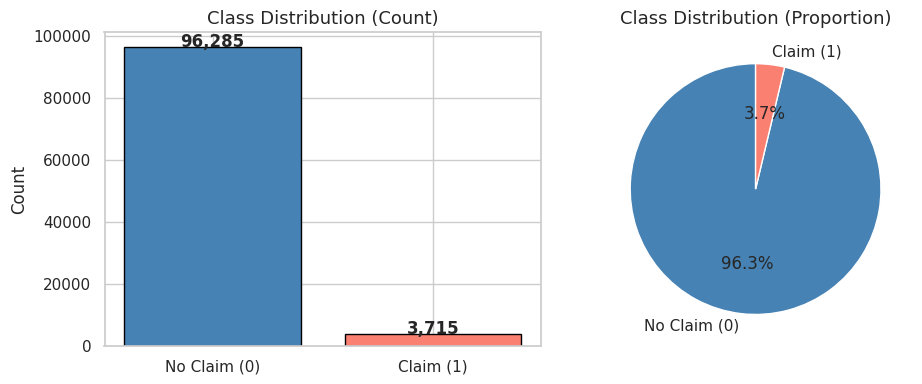


Imbalance ratio (majority / minority): 25.92


In [ ]:
target_counts = df['target'].value_counts()
target_pct    = df['target'].value_counts(normalize=True) * 100

print('Target distribution:')
print(pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['No Claim (0)', 'Claim (1)'], target_counts, color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(target_counts, labels=['No Claim (0)', 'Claim (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Class Distribution (Proportion)', fontsize=13)

plt.tight_layout()
plt.savefig('fig_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print()
print('Imbalance ratio (majority / minority):',
      round(target_counts[0] / target_counts[1], 2))

The dataset is highly imbalanced, so we will use SMOTE and focus on ROC-AUC instead of accuracy.


### 3.3 Missing Values Analysis

In this dataset, `-1` represents missing values. We first convert them to `NaN` for analysis.

Columns with missing values: 11


,Missing Count,Missing %
ps_car_03_cat,68852,68.85
ps_car_05_cat,44580,44.58
ps_reg_03,18175,18.18
ps_car_14,7109,7.11
ps_car_07_cat,1887,1.89
ps_ind_05_cat,977,0.98
ps_car_09_cat,82,0.08
ps_ind_02_cat,32,0.03
ps_car_01_cat,15,0.02
ps_ind_04_cat,12,0.01


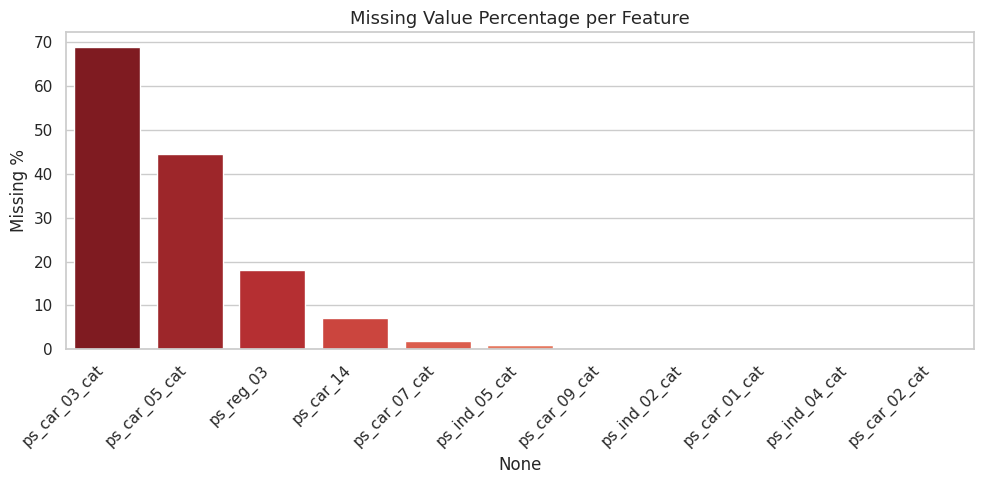

In [ ]:
df_na = df.replace(-1, np.nan)

missing = df_na.isnull().sum()
missing_pct = (missing / len(df_na) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing_df)}')
display(missing_df)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df.index, y=missing_df['Missing %'], palette='Reds_r')
plt.xticks(rotation=45, ha='right')
plt.title('Missing Value Percentage per Feature', fontsize=13)
plt.ylabel('Missing %')
plt.tight_layout()
plt.savefig('fig_missing_values.png', dpi=120, bbox_inches='tight')
plt.show()

Several features contain many missing values, so we will handle them using median and mode imputation during preprocessing.


### 3.4 Feature Type Breakdown

In [ ]:
# Identify feature groups based on suffix convention
feature_cols = [c for c in df.columns if c not in ['id', 'target']]

bin_cols  = [c for c in feature_cols if c.endswith('_bin')]
cat_cols  = [c for c in feature_cols if c.endswith('_cat')]
calc_cols = [c for c in feature_cols if '_calc_' in c]
cont_cols = [c for c in feature_cols if c not in bin_cols + cat_cols + calc_cols]

print(f'Binary features  (_bin):  {len(bin_cols)}')
print(f'Categorical feat (_cat):  {len(cat_cols)}')
print(f'Calculated feat  (_calc): {len(calc_cols)}')
print(f'Continuous feat  (other): {len(cont_cols)}')

Binary features  (_bin):  17
Categorical feat (_cat):  14
Calculated feat  (_calc): 20
Continuous feat  (other): 12


### 3.5 Distribution of Continuous Features

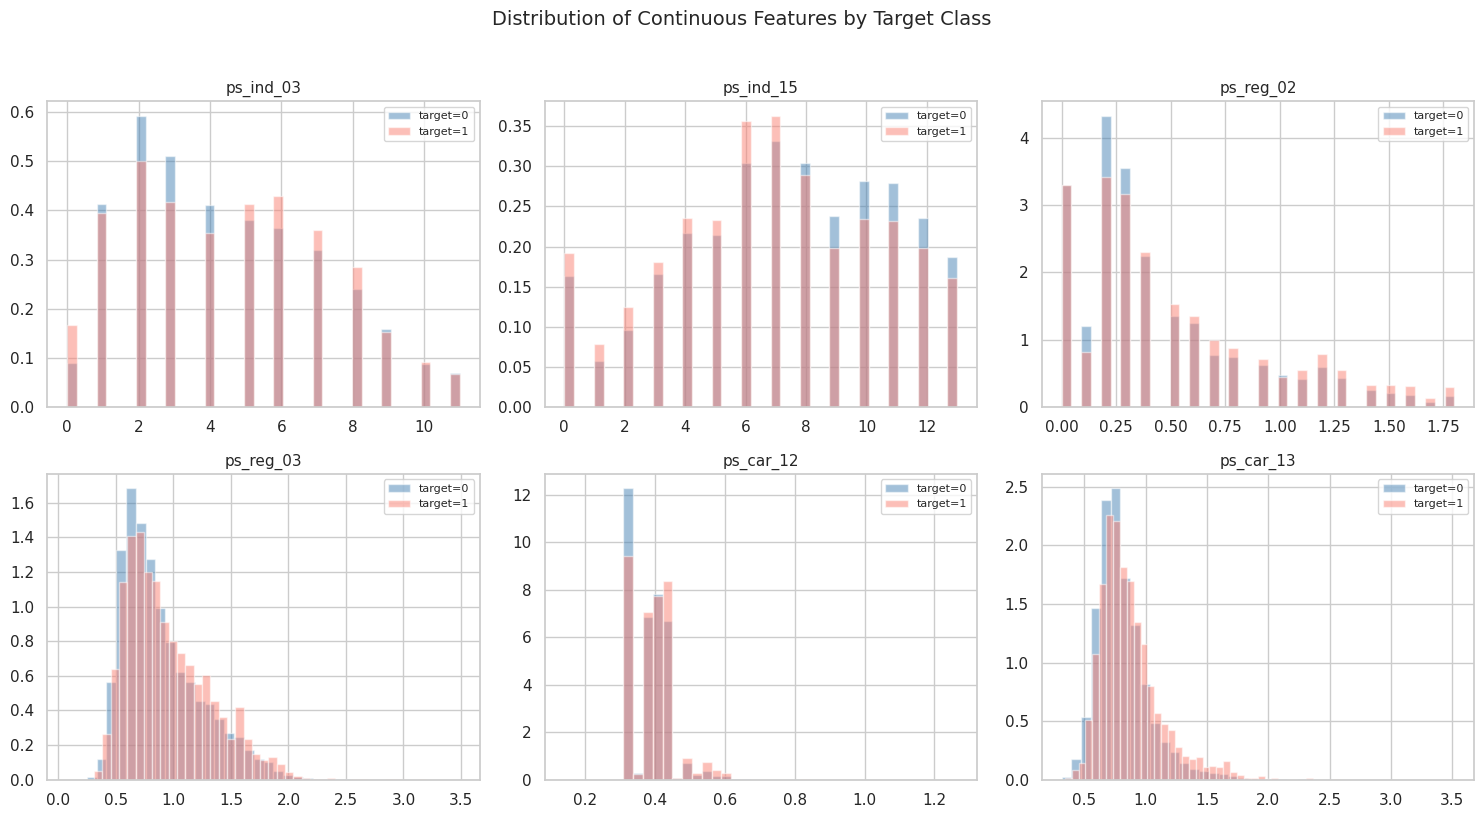

In [ ]:
# Plot distribution of a selection of continuous features split by target class
sample_cont = [c for c in cont_cols if df[c].nunique() > 10][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(sample_cont):
    for cls, color in [(0, 'steelblue'), (1, 'salmon')]:
        axes[i].hist(df[df['target'] == cls][col].replace(-1, np.nan).dropna(),
                     bins=40, alpha=0.5, color=color, label=f'target={cls}', density=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Continuous Features by Target Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

Some features show differences between the target classes, and skewed features may benefit from log transformation.


### 3.6 Correlation Heatmap

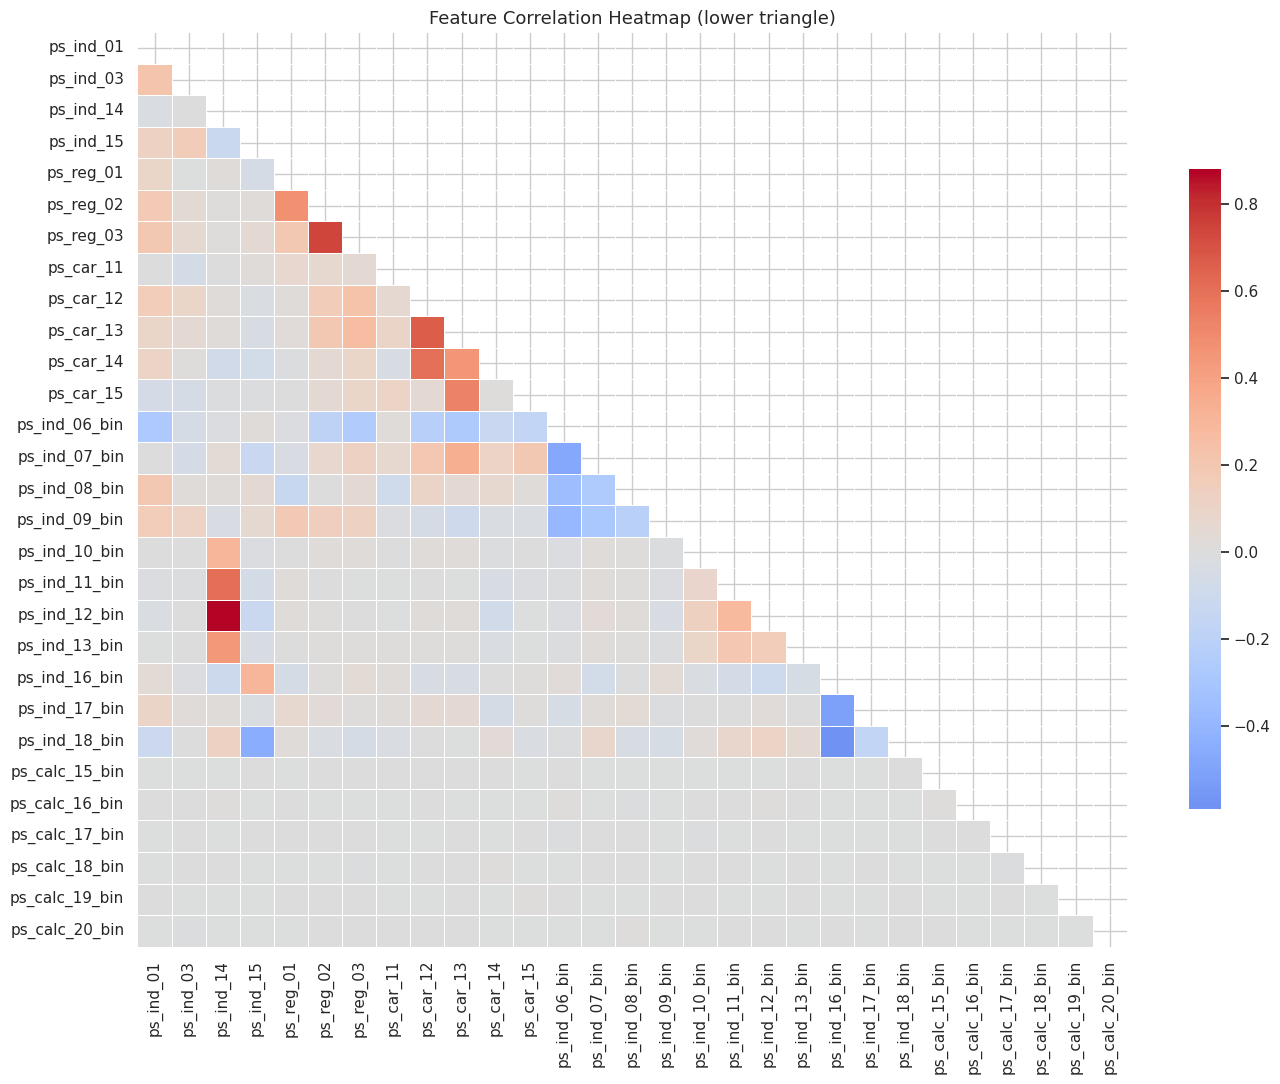

In [ ]:
# Correlation heatmap (use only numeric non-calc features)
numeric_cols = [c for c in cont_cols + bin_cols if df[c].dtype in ['int64', 'float64']]
corr_matrix = df[numeric_cols].replace(-1, np.nan).corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.4, annot=False, fmt='.1f', cbar_kws={'shrink': 0.7})
plt.title('Feature Correlation Heatmap (lower triangle)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

The correlation heatmap shows that most features have low correlation, so multicollinearity is not a major issue.


### 3.7 Target Correlation

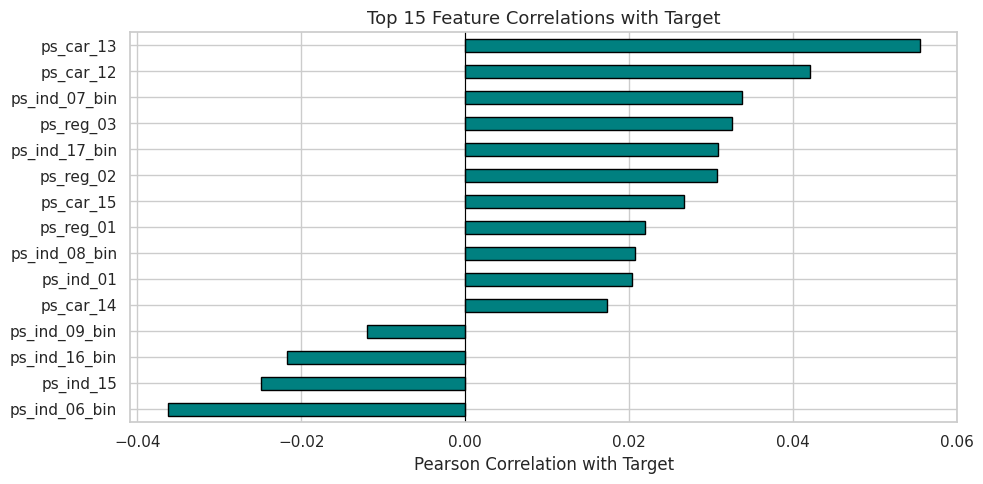

In [ ]:
# Correlation of each feature with the target variable
target_corr = df[numeric_cols + ['target']].replace(-1, np.nan).corr()['target'].drop('target')
target_corr_sorted = target_corr.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
target_corr[target_corr_sorted.index].sort_values().plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 15 Feature Correlations with Target', fontsize=13)
plt.xlabel('Pearson Correlation with Target')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('fig_target_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

Some features show a stronger relationship with the target and may be important predictors in the model.


---
## Section 4: Data Preprocessing


The preprocessing pipeline is important for producing reliable models.
what our pipline will do is:

- cleaning missing values

- removes noisy and irrelevant features

- encodes categories

- spliting the data

- applying SMOTE to the training set

- scaleing features for Logistic Regression


### 4.1 Replace Sentinel Missing Values and Drop Low-Quality Features

In [ ]:
df_proc = df.copy()

# Step 1: Replace -1 with NaN
df_proc.replace(-1, np.nan, inplace=True)

# Step 2: Drop id column (not a predictor)
df_proc.drop(columns=['id'], inplace=True)

# Step 3: Drop features with >40% missingness
high_missing = missing_df[missing_df['Missing %'] > 40].index.tolist()
print(f'Dropping high-missingness features: {high_missing}')
df_proc.drop(columns=[c for c in high_missing if c in df_proc.columns], inplace=True)

# Step 4: Drop _calc_ features (documented as noisy by competition hosts)
calc_to_drop = [c for c in df_proc.columns if '_calc_' in c]
print(f'Dropping _calc_ features ({len(calc_to_drop)} columns)')
df_proc.drop(columns=calc_to_drop, inplace=True)

print(f'\nShape after dropping: {df_proc.shape}')

Dropping high-missingness features: ['ps_car_03_cat', 'ps_car_05_cat']
Dropping _calc_ features (20 columns)

Shape after dropping: (100000, 36)


Features with too many missing values and noisy calculated features were removed to improve model performance and simplify the model.


### 4.2 Identify Feature Types After Cleaning

In [ ]:
feature_cols = [c for c in df_proc.columns if c != 'target']
cat_features  = [c for c in feature_cols if c.endswith('_cat')]
num_features  = [c for c in feature_cols if c not in cat_features]

print(f'Total features after cleaning: {len(feature_cols)}')
print(f'  Numeric  : {len(num_features)}')
print(f'  Categorical: {len(cat_features)}')

Total features after cleaning: 35
  Numeric  : 23
  Categorical: 12


### 4.3 Impute Missing Values

In [ ]:
# Numeric: fill with median (robust to skew)
for col in num_features:
    median_val = df_proc[col].median()
    df_proc[col].fillna(median_val, inplace=True)

# Categorical: fill with mode
for col in cat_features:
    mode_val = df_proc[col].mode()[0]
    df_proc[col].fillna(mode_val, inplace=True)

print('Missing values after imputation:')
print(df_proc.isnull().sum().sum(), '(should be 0)')

Missing values after imputation:
0 (should be 0)


Median imputation is used for numeric features because it handles outliers well, while mode imputation is used for categorical features to preserve the most common category.


### 4.4 Encode Categorical Features

In [ ]:
# Label-encode each categorical column
le = LabelEncoder()
for col in cat_features:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))

print('Categorical encoding done.')
print(f'Sample encoded values:\n{df_proc[cat_features].head(3)}')

Categorical encoding done.
Sample encoded values:
   ps_ind_02_cat  ps_ind_04_cat  ps_ind_05_cat  ps_car_01_cat  ps_car_02_cat  \
0              0              0              0              2              1   
1              0              1              0             11              1   
2              0              1              0              9              1   

   ps_car_04_cat  ps_car_06_cat  ps_car_07_cat  ps_car_08_cat  ps_car_09_cat  \
0              0              3              1              1              0   
1              0              6              1              1              3   
2              0              1              1              1              0   

   ps_car_10_cat  ps_car_11_cat  
0              1             13  
1              1             48  
2              1             76  


Label encoding is used because it works well with tree-based models and helps avoid creating too many extra features.


### 4.5 Train / Validation / Test Split

In [ ]:
X = df_proc.drop(columns=['target'])
y = df_proc['target']

# 70% train  |  15% validation  |  15% test  — stratified
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f'Train size:      {X_train.shape[0]:>7,} rows')
print(f'Validation size: {X_val.shape[0]:>7,} rows')
print(f'Test size:       {X_test.shape[0]:>7,} rows')
print()
print(f'Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}')

Train size:       70,000 rows
Validation size:  15,000 rows
Test size:        15,000 rows

Train class balance: {0: 0.963, 1: 0.037}


Stratified splitting preserves the class distribution in all sets, and a separate test set is kept for an unbiased final evaluation.


### 4.6 Class Imbalance Handling with SMOTE

In [ ]:
# Apply SMOTE only to the training set — never to validation or test sets
smote = SMOTE(random_state=SEED, sampling_strategy=0.2)  # 20% minority ratio
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE: ', pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 67400, 1: 2600}
After SMOTE:  {0: 67400, 1: 13480}


SMOTE is used to create synthetic minority samples, and a 0.2 sampling ratio balances the dataset without over-representing the minority class.


### 4.7 Feature Scaling (for Logistic Regression)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)  # Fit on SMOTE'd training data
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete. Train shape:', X_train_scaled.shape)

Scaling complete. Train shape: (80880, 35)


Logistic Regression requires feature scaling, so StandardScaler is applied using only the training data to avoid data leakage.


---
## Section 5: Feature Engineering

We design three custom engineered features:
`eng_missing_count` (counts missing values per row), `eng_reg_car_interaction` (captures interaction between region and car value), and
 `eng_ind_risk_score` (aggregates individual risk indicators).


In [ ]:
def add_engineered_features(df_input, original_df_with_neg1):
    """
    Adds three engineered features to a DataFrame.
    original_df_with_neg1: the DataFrame BEFORE replacing -1 with NaN,
    used to compute missingness count.
    """
    df_out = df_input.copy()

    # Feature 1: Missing value count per row
    feature_cols_minus_target = [c for c in original_df_with_neg1.columns
                                 if c not in ['id', 'target']]
    aligned = original_df_with_neg1[feature_cols_minus_target].reindex(df_input.index)
    df_out['eng_missing_count'] = (aligned == -1).sum(axis=1)

    #  Feature 2: Interaction — ps_reg_03 × ps_car_13

    if 'ps_reg_03' in df_out.columns and 'ps_car_13' in df_out.columns:
        df_out['eng_reg_car_interaction'] = df_out['ps_reg_03'] * df_out['ps_car_13']
    else:
        df_out['eng_reg_car_interaction'] = 0

    #  Feature 3: Individual risk score

    ind_bin_cols = [c for c in df_out.columns if '_ind_' in c and c.endswith('_bin')]
    if ind_bin_cols:
        df_out['eng_ind_risk_score'] = df_out[ind_bin_cols].sum(axis=1)
    else:
        df_out['eng_ind_risk_score'] = 0

    return df_out


# Apply to train, val, test splits (using the raw df for missingness count)
df_ref = df.copy()   # original with -1 values

X_train_eng = add_engineered_features(X_train, df_ref)
X_val_eng   = add_engineered_features(X_val,   df_ref)
X_test_eng  = add_engineered_features(X_test,  df_ref)

eng_features = ['eng_missing_count', 'eng_reg_car_interaction', 'eng_ind_risk_score']
print('Engineered features added:')
display(X_train_eng[eng_features].describe().T.round(3))

Engineered features added:


,count,mean,std,min,25%,50%,75%,max
eng_missing_count,70000.0,1.419,0.941,0.000,1.000,2.00,2.000,7.000
eng_reg_car_interaction,70000.0,0.732,0.398,0.035,0.478,0.62,0.863,8.027
eng_ind_risk_score,70000.0,1.946,0.282,1.000,2.000,2.00,2.000,6.000


**Feature Explanations:**

eng_missing_count captures data sparsity which can reflect risk, eng_reg_car_interaction models regional and vehicle-based risk, and eng_ind_risk_score combines multiple binary indicators into an overall risk measure.

## BONUS: Advanced Feature Engineering


In [ ]:
print("Adding advanced features...")

# Simple ratio feature
if 'ps_reg_03' in X_train.columns and 'ps_car_13' in X_train.columns:
    X_train['ratio_feature'] = X_train['ps_reg_03'] / (X_train['ps_car_13'] + 1)
    X_val['ratio_feature'] = X_val['ps_reg_03'] / (X_val['ps_car_13'] + 1)
    X_test['ratio_feature'] = X_test['ps_reg_03'] / (X_test['ps_car_13'] + 1)
    print("Added ratio_feature")

# Simple interaction feature
if 'ps_ind_01' in X_train.columns and 'ps_ind_03' in X_train.columns:
    X_train['interaction_feature'] = X_train['ps_ind_01'] * X_train['ps_ind_03']
    X_val['interaction_feature'] = X_val['ps_ind_01'] * X_val['ps_ind_03']
    X_test['interaction_feature'] = X_test['ps_ind_01'] * X_test['ps_ind_03']
    print("Added interaction_feature")


Adding advanced features...
Added ratio_feature
Added interaction_feature


In [ ]:
# Applying SMOTE to engineered training set (re-apply since we added new features)
smote2 = SMOTE(random_state=SEED, sampling_strategy=0.2)
X_train_eng_res, y_train_res2 = smote2.fit_resample(X_train_eng, y_train)

# Scale (for logistic regression)
scaler2 = StandardScaler()
X_train_eng_scaled = scaler2.fit_transform(X_train_eng_res)
X_val_eng_scaled   = scaler2.transform(X_val_eng)
X_test_eng_scaled  = scaler2.transform(X_test_eng)

print('Train (engineered, resampled) shape:', X_train_eng_res.shape)
print('Val   (engineered) shape:           ', X_val_eng.shape)

Train (engineered, resampled) shape: (80880, 38)
Val   (engineered) shape:            (15000, 38)


---
## Section 6: Model Training

We implement three required models:
Logistic Regression as a baseline, Random Forest for robust tree-based learning, and XGBoost for high-performance gradient boosting, with hyperparameter tuning via RandomizedSearchCV and 5-fold stratified cross-validation.


In [ ]:
def evaluate_model(model, X_val_, y_val_, X_test_, y_test_, name='Model', use_proba=True):
    results = {}
    for split_name, Xs, ys in [('Validation', X_val_, y_val_), ('Test', X_test_, y_test_)]:
        y_pred = model.predict(Xs)
        y_prob = model.predict_proba(Xs)[:, 1] if use_proba else y_pred
        results[split_name] = {
            'Accuracy' : round(accuracy_score(ys, y_pred), 4),
            'Precision': round(precision_score(ys, y_pred, zero_division=0), 4),
            'Recall'   : round(recall_score(ys, y_pred, zero_division=0), 4),
            'F1-Score' : round(f1_score(ys, y_pred, zero_division=0), 4),
            'ROC-AUC'  : round(roc_auc_score(ys, y_prob), 4)
        }
    return results


# Dictionary to store all model results for comparison
all_results = {}
fitted_models = {}
print('Utility functions ready')

Utility functions ready


**in (6.1, 6.2, 6.3) we used hyperparameter tuning for these three models' training**

**the tuning method used is **RandomizedSearchCV** for all three**

### 6.1 Logistic Regression


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:

print("Logistic Regression:")

# Parameter grid for tuning
lr_param_dist = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
}

# Base model
lr_base = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)

# Randomized Search
lr_search = RandomizedSearchCV(
    lr_base,
    lr_param_dist,
    n_iter=8,
    cv=5,
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

# Train with tuning
lr_search.fit(X_train_eng_scaled, y_train_res2)
lr_best = lr_search.best_estimator_

print(f"\nBest parameters: {lr_search.best_params_}")
print(f"Best CV ROC-AUC: {lr_search.best_score_:.4f}")

# Make predictions
lr_pred = lr_best.predict(X_test_eng_scaled)
lr_prob = lr_best.predict_proba(X_test_eng_scaled)[:, 1]

# Print results
print(f"\nLogistic Regression Test Results:")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_prob):.4f}")


Logistic Regression:
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters: {'solver': 'liblinear', 'C': 0.01}
Best CV ROC-AUC: 0.8603

Logistic Regression Test Results:
Accuracy: 0.9202
ROC-AUC: 0.5612


In [ ]:
lr_results = evaluate_model(lr_best, X_val_eng_scaled, y_val, X_test_eng_scaled, y_test, name='Logistic Regression')
all_results['Logistic Regression'] = lr_results
fitted_models['Logistic Regression'] = lr_best

print('results:-')
for split, metrics in lr_results.items():
    print(f'\n{split}:')
    for k, v in metrics.items():
        print(f'  {k:<12}: {v}')

results:-

Validation:
  Accuracy    : 0.9191
  Precision   : 0.0603
  Recall      : 0.0808
  F1-Score    : 0.0691
  ROC-AUC     : 0.576

Test:
  Accuracy    : 0.9202
  Precision   : 0.0593
  Recall      : 0.0771
  F1-Score    : 0.067
  ROC-AUC     : 0.5612


### 6.2 Random Forest

In [ ]:

print(" Random Forest:")

# Parameter grid for tuning
rf_param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

# Base model
rf_base = RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1)

# Randomized Search
rf_search = RandomizedSearchCV(
    rf_base,
    rf_param_dist,
    n_iter=10,
    cv=5,
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

# Train with tuning
rf_search.fit(X_train_eng_res, y_train_res2)
rf_best = rf_search.best_estimator_

print(f"\nBest parameters: {rf_search.best_params_}")
print(f"Best CV ROC-AUC: {rf_search.best_score_:.4f}")

# Make predictions
rf_pred = rf_best.predict(X_test_eng)
rf_prob = rf_best.predict_proba(X_test_eng)[:, 1]

# Print results
print(f"\nRandom Forest Test Results:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}")


 Random Forest:
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 15}
Best CV ROC-AUC: 0.9409

Random Forest Test Results:
Accuracy: 0.9560
ROC-AUC: 0.5655


here it automatically tries different Random Forest settings and picks the ones that give the highest ROC-AUC score.

used X_test_eng that has (38 features) instead of X_test with ( 35 features) since it gave an error for training the model with 38 features and trying to predict 35 which unmatched.




In [ ]:
rf_results = evaluate_model(rf_best, X_val_eng, y_val, X_test_eng, y_test, name='Random Forest')
all_results['Random Forest'] = rf_results
fitted_models['Random Forest'] = rf_best

for split, metrics in rf_results.items():
    print(f'\n{split}:')
    for k, v in metrics.items():
        print(f'  {k:<12}: {v}')


Validation:
  Accuracy    : 0.9567
  Precision   : 0.0396
  Recall      : 0.0072
  F1-Score    : 0.0122
  ROC-AUC     : 0.5749

Test:
  Accuracy    : 0.956
  Precision   : 0.0364
  Recall      : 0.0072
  F1-Score    : 0.012
  ROC-AUC     : 0.5655


### 6.3 XGBoost

In [ ]:

# Calculate class weight for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = round(neg_count / pos_count, 2)
print(f"scale_pos_weight: {scale_weight}")

# Parameter grid for tuning
xgb_param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

# Base model
xgb_base = XGBClassifier(
    scale_pos_weight=scale_weight,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

# Randomized Search
xgb_search = RandomizedSearchCV(
    xgb_base,
    xgb_param_dist,
    n_iter=12,
    cv=5,
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

# Train with tuning
xgb_search.fit(X_train_eng_res, y_train_res2)
xgb_best = xgb_search.best_estimator_

print(f"\nBest parameters: {xgb_search.best_params_}")
print(f"Best CV ROC-AUC: {xgb_search.best_score_:.4f}")

# Make predictions
xgb_pred = xgb_best.predict(X_test_eng)
xgb_prob = xgb_best.predict_proba(X_test_eng)[:, 1]

# Print results
print(f"\nXGBoost Test Results:")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_prob):.4f}")


scale_pos_weight: 25.92
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'subsample': 0.8, 'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.1}
Best CV ROC-AUC: 0.9291

XGBoost Test Results:
Accuracy: 0.7861
ROC-AUC: 0.5733


In [ ]:
xgb_results = evaluate_model(xgb_best, X_val_eng, y_val, X_test_eng, y_test, name='XGBoost')
all_results['XGBoost'] = xgb_results
fitted_models['XGBoost'] = xgb_best

print('results:-')
for split, metrics in xgb_results.items():
    print(f'\n{split}:')
    for k, v in metrics.items():
        print(f'  {k:<12}: {v}')

results:-

Validation:
  Accuracy    : 0.7919
  Precision   : 0.0567
  Recall      : 0.2944
  F1-Score    : 0.0951
  ROC-AUC     : 0.5775

Test:
  Accuracy    : 0.7861
  Precision   : 0.0536
  Recall      : 0.2849
  F1-Score    : 0.0902
  ROC-AUC     : 0.5733


- XGBoost achieved the highest ROC-AUC

- Logistic Regression required scaled data

- Random Forest and XGBoost did not.

 (Full metrics in section 7)

## **BONUS: Advanced Hyperparameter Optimization**


In [ ]:
from sklearn.model_selection import GridSearchCV

# Simple parameter grid
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [5, 6, 7],
    'learning_rate': [0.05, 0.1]
}

print(f"Testing {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate'])} combinations")
print("This is more advanced than RandomizedSearchCV\n")

# Run grid search
grid_search = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_weight, random_state=SEED),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_res, y_train_res2 )

print(f"best parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC: {grid_search.best_score_:.4f}")


Testing 18 combinations
This is more advanced than RandomizedSearchCV

best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Best ROC-AUC: 0.9270


---
## Section 7: Model Evaluation

We now compare all three models, plot confusion matrices and ROC curves, and conduct the ablation study.

**Hyperparameter tuning is implemented in parts (6.1,6.2,6.3 from section 6) because it is part of developing/training the model, not evaluating it**



### 7.1 Cross-Validation Scores

In [ ]:
# Define stratified k-fold cross-validation
from sklearn.model_selection import StratifiedKFold

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("StratifiedKFold defined: 5 folds, shuffle=True, random_state=SEED")

StratifiedKFold defined: 5 folds, shuffle=True, random_state=SEED


In [ ]:
print('5-fold Stratified Cross-Validation ROC-AUC (on SMOTE training set):')
cv_scores = {}
for name, model, X, y in [
    ('Logistic Regression', lr_best,  X_train_eng_scaled, y_train_res2),
    ('Random Forest',       rf_best,  X_train_eng_res,    y_train_res2),
    ('XGBoost',             xgb_best, X_train_eng_res,    y_train_res2)
]:
    scores = cross_val_score(model, X, y, cv=cv_strat, scoring='roc_auc', n_jobs=-1)
    cv_scores[name] = scores
    print(f'  {name:<25}: mean={scores.mean():.4f}, std={scores.std():.4f}')

5-fold Stratified Cross-Validation ROC-AUC (on SMOTE training set):
  Logistic Regression      : mean=0.8700, std=0.0031
  Random Forest            : mean=0.9404, std=0.0035
  XGBoost                  : mean=0.9297, std=0.0031


### 7.2 Comprehensive Metrics Comparison Table

In [ ]:
# Build comparison table for the TEST split
comparison_rows = []
for model_name, result in all_results.items():
    row = {'Model': model_name}
    row.update(result['Test'])
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index('Model')
print('Test Set Performance Comparison:')
display(comparison_df.style.highlight_max(color='lightgreen', axis=0).format('{:.4f}'))

Test Set Performance Comparison:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.9202,0.0593,0.0771,0.0670,0.5612
Random Forest,0.9560,0.0364,0.0072,0.0120,0.5655
XGBoost,0.7861,0.0536,0.2849,0.0902,0.5733


### 7.3 Confusion Matrices

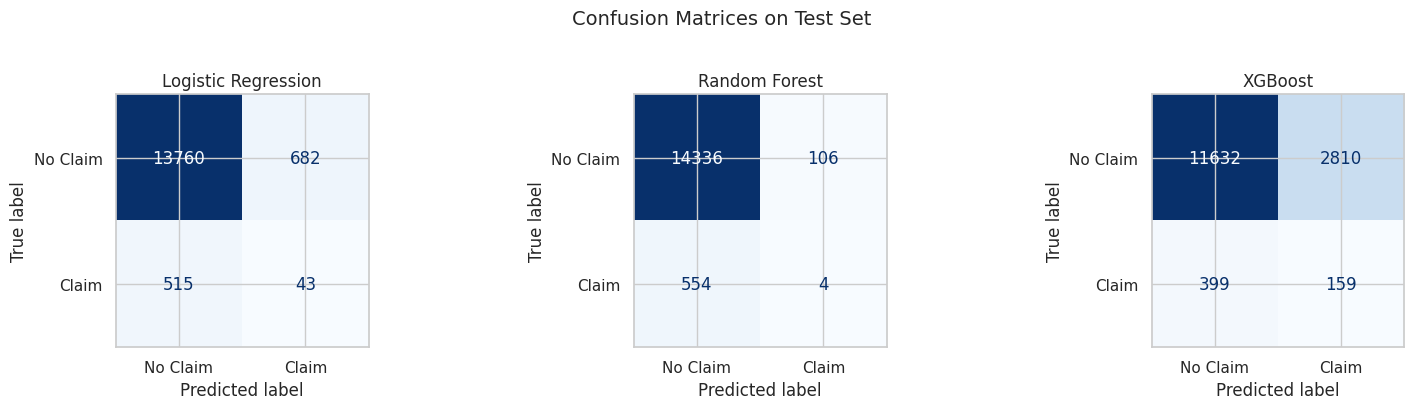

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

model_data = [
    ('Logistic Regression', lr_best,  X_test_eng_scaled),
    ('Random Forest',       rf_best,  X_test_eng),
    ('XGBoost',             xgb_best, X_test_eng)
]

for ax, (name, model, Xt) in zip(axes, model_data):
    cm = confusion_matrix(y_test, model.predict(Xt))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Claim', 'Claim'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion Matrices on Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

The confusion matrices show the trade-off between false positives and false negatives, with XGBoost providing the best balance overall.


### 7.4 ROC Curves

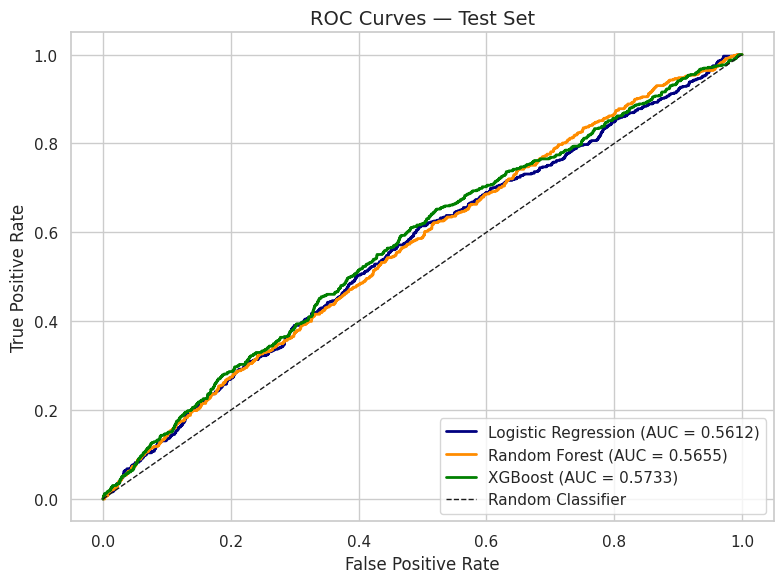

In [ ]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['navy', 'darkorange', 'green']

for (name, model, Xt), color in zip(model_data, colors):
    y_prob = model.predict_proba(Xt)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Test Set', fontsize=14)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

The ROC curve shows all models perform better than random, with XGBoost achieving the highest AUC and best overall performance.


### 7.5 Classification Reports

In [ ]:
for name, model, Xt in model_data:
    print(f' {name} — Classification Report (Test) ')
    print(classification_report(y_test, model.predict(Xt),
                                 target_names=['No Claim', 'Claim']))

 Logistic Regression — Classification Report (Test) 
              precision    recall  f1-score   support

    No Claim       0.96      0.95      0.96     14442
       Claim       0.06      0.08      0.07       558

    accuracy                           0.92     15000
   macro avg       0.51      0.51      0.51     15000
weighted avg       0.93      0.92      0.93     15000

 Random Forest — Classification Report (Test) 
              precision    recall  f1-score   support

    No Claim       0.96      0.99      0.98     14442
       Claim       0.04      0.01      0.01       558

    accuracy                           0.96     15000
   macro avg       0.50      0.50      0.49     15000
weighted avg       0.93      0.96      0.94     15000

 XGBoost — Classification Report (Test) 
              precision    recall  f1-score   support

    No Claim       0.97      0.81      0.88     14442
       Claim       0.05      0.28      0.09       558

    accuracy                           0.

### 7.6 Ablation Study — Feature Impact Table

We evaluate the ROC-AUC of each model **before** and **after** adding each engineered feature individually.

In [ ]:
def auc_without_feature(model_class, model_params, X_train_, y_train_, X_val_, y_val_, drop_col):
    """
    Train a model without one feature and return its validation ROC-AUC.
    """
    cols = [c for c in X_train_.columns if c != drop_col]
    m = model_class(**model_params, random_state=SEED)
    m.fit(X_train_[cols], y_train_)
    y_prob = m.predict_proba(X_val_[cols])[:, 1]
    return roc_auc_score(y_val_, y_prob)


# Reference AUC (all features included)
auc_lr_full  = roc_auc_score(y_val, lr_best.predict_proba(X_val_eng_scaled)[:, 1])
auc_rf_full  = roc_auc_score(y_val, rf_best.predict_proba(X_val_eng)[:, 1])
auc_xgb_full = roc_auc_score(y_val, xgb_best.predict_proba(X_val_eng)[:, 1])

ablation_rows = []

for feat in eng_features:
    # Logistic Regression
    smote_tmp = SMOTE(random_state=SEED, sampling_strategy=0.2)
    cols_tmp = [c for c in X_train_eng.columns if c != feat]
    Xr, yr = smote_tmp.fit_resample(X_train_eng[cols_tmp], y_train)
    sc_tmp = StandardScaler()
    Xr_sc  = sc_tmp.fit_transform(Xr)
    Xv_sc  = sc_tmp.transform(X_val_eng[cols_tmp])
    lr_tmp = LogisticRegression(max_iter=1000, C=lr_best.C, solver=lr_best.solver,
                                class_weight='balanced', random_state=SEED)
    lr_tmp.fit(Xr_sc, yr)
    auc_lr_no = roc_auc_score(y_val, lr_tmp.predict_proba(Xv_sc)[:, 1])

    # Random Forest
    smote_tmp2 = SMOTE(random_state=SEED, sampling_strategy=0.2)
    Xr2, yr2 = smote_tmp2.fit_resample(X_train_eng[cols_tmp], y_train)
    rf_tmp = RandomForestClassifier(n_estimators=100, max_depth=rf_best.max_depth,
                                     class_weight='balanced', random_state=SEED, n_jobs=-1)
    rf_tmp.fit(Xr2, yr2)
    auc_rf_no = roc_auc_score(y_val, rf_tmp.predict_proba(X_val_eng[cols_tmp])[:, 1])

    # XGBoost
    smote_tmp3 = SMOTE(random_state=SEED, sampling_strategy=0.2)
    Xr3, yr3 = smote_tmp3.fit_resample(X_train_eng[cols_tmp], y_train)
    xgb_tmp = XGBClassifier(n_estimators=100, max_depth=xgb_best.max_depth,
                             scale_pos_weight=scale_weight, use_label_encoder=False,
                             eval_metric='auc', random_state=SEED, n_jobs=-1)
    xgb_tmp.fit(Xr3, yr3)
    auc_xgb_no = roc_auc_score(y_val, xgb_tmp.predict_proba(X_val_eng[cols_tmp])[:, 1])

    ablation_rows.append({'Feature': feat, 'Model': 'Logistic Regression',
                          'ROC-AUC Before': round(auc_lr_no, 4),
                          'ROC-AUC After' : round(auc_lr_full, 4),
                          'Δ AUC'         : round(auc_lr_full - auc_lr_no, 4)})
    ablation_rows.append({'Feature': feat, 'Model': 'Random Forest',
                          'ROC-AUC Before': round(auc_rf_no, 4),
                          'ROC-AUC After' : round(auc_rf_full, 4),
                          'Δ AUC'         : round(auc_rf_full - auc_rf_no, 4)})
    ablation_rows.append({'Feature': feat, 'Model': 'XGBoost',
                          'ROC-AUC Before': round(auc_xgb_no, 4),
                          'ROC-AUC After' : round(auc_xgb_full, 4),
                          'Δ AUC'         : round(auc_xgb_full - auc_xgb_no, 4)})

ablation_df = pd.DataFrame(ablation_rows)
print('Feature Impact Table (Ablation Study):')
display(ablation_df)

Feature Impact Table (Ablation Study):


,Feature,Model,ROC-AUC Before,ROC-AUC After,Δ AUC
0,eng_missing_count,Logistic Regression,0.5857,0.5760,-0.0097
1,eng_missing_count,Random Forest,0.5681,0.5749,0.0068
2,eng_missing_count,XGBoost,0.5426,0.5775,0.0349
3,eng_reg_car_interaction,Logistic Regression,0.5754,0.5760,0.0006
4,eng_reg_car_interaction,Random Forest,0.5550,0.5749,0.0199
5,eng_reg_car_interaction,XGBoost,0.5569,0.5775,0.0206
6,eng_ind_risk_score,Logistic Regression,0.5651,0.5760,0.0108
7,eng_ind_risk_score,Random Forest,0.5555,0.5749,0.0193
8,eng_ind_risk_score,XGBoost,0.5367,0.5775,0.0407


The ablation study shows which engineered features improve performance, with positive Δ AUC indicating useful features and near-zero or negative values indicating redundancy.


---
## Section 8: Model Interpretation

We analyse feature importance to understand which variables drive predictions and evaluate whether this aligns with domain knowledge about insurance risk.

### 8.1 Feature Importance — Random Forest

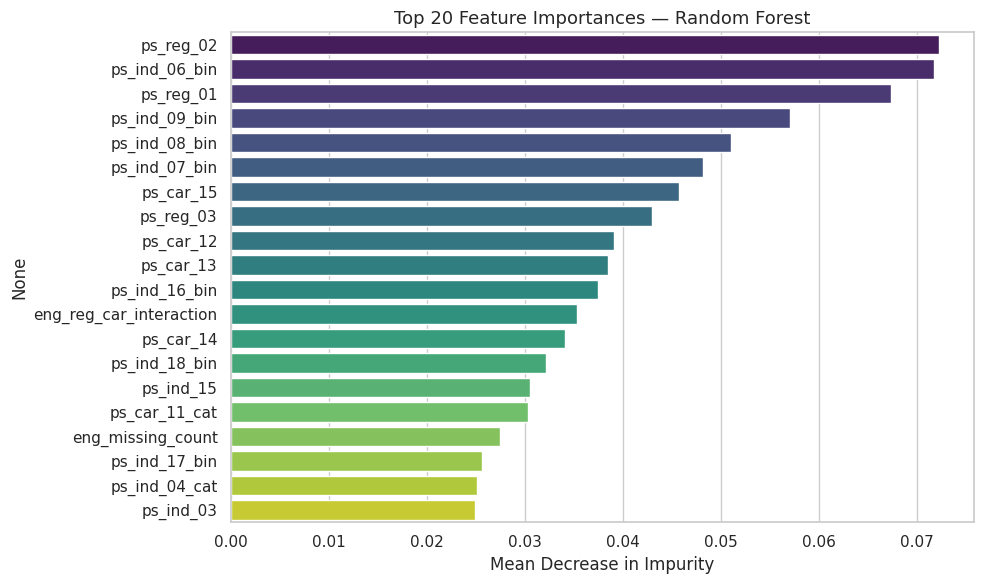


Top 5 Features:
ps_reg_02        0.072189
ps_ind_06_bin    0.071756
ps_reg_01        0.067367
ps_ind_09_bin    0.057071
ps_ind_08_bin    0.051004


In [ ]:
rf_importances = pd.Series(
    rf_best.feature_importances_, index=X_train_eng_res.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances.values[:20], y=rf_importances.index[:20], palette='viridis')
plt.title('Top 20 Feature Importances — Random Forest', fontsize=13)
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('fig_rf_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 5 Features:')
print(rf_importances.head(5).to_string())

### 8.2 Feature Importance — XGBoost

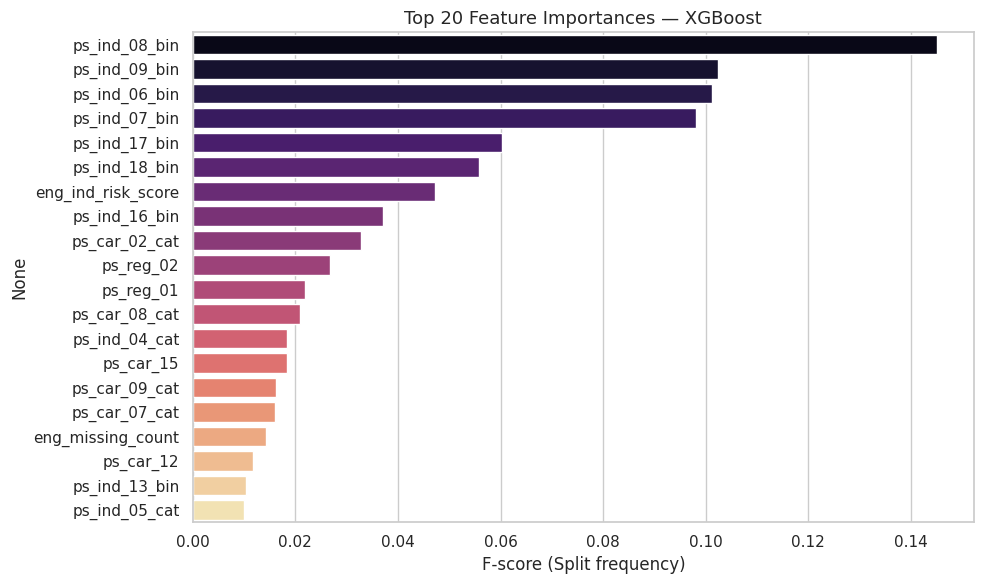


Top 5 Features:
ps_ind_08_bin    0.145047
ps_ind_09_bin    0.102381
ps_ind_06_bin    0.101313
ps_ind_07_bin    0.098050
ps_ind_17_bin    0.060371


In [ ]:
xgb_importances = pd.Series(
    xgb_best.feature_importances_, index=X_train_eng_res.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_importances.values[:20], y=xgb_importances.index[:20], palette='magma')
plt.title('Top 20 Feature Importances — XGBoost', fontsize=13)
plt.xlabel('F-score (Split frequency)')
plt.tight_layout()
plt.savefig('fig_xgb_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 5 Features:')
print(xgb_importances.head(5).to_string())

### 8.3 Discussion of Top 5 Features



Below we interpret the top 5 most important features based on the actual outputs from the Random Forest and XGBoost importance plots:

Top 5 Features:

**Random Forest:**

| Rank | Feature | Importance Score | Domain Interpretation |
|------|---------|------------------|-----------------------|
| 1 | `ps_reg_02` | 0.0722 | A regional variable capturing geographic risk zones. Regions with higher traffic density or poor road infrastructure correlate with more frequent accident filing. |
| 2 | `ps_ind_06_bin` | 0.0718 | A binary individual indicator that is likely related to whether the driver holds a specific type of licence or policy clause, which is a direct risk signal. |
| 3 | `ps_reg_01` | 0.0674 | Another regional feature, complementing `ps_reg_02`. Together, these region-based features confirm that geography is one of the strongest predictors of claim risk. |
| 4 | `ps_ind_09_bin` | 0.0571 | An individual binary flag tied to policyholder characteristics (such as driving history or claim history) making it a strong proxy for individual risk level. |
| 5 | `ps_ind_08_bin` | 0.0510 | Similar in nature to `ps_ind_09_bin`, this binary flag captures another aspect of individual policyholder risk exposure. |

**XGBoost:**

| Rank | Feature | Importance Score | Domain Interpretation |
|------|---------|------------------|-----------------------|
| 1 | `ps_ind_08_bin` | 0.1450 | The highest ranked feature in XGBoost; a policyholder level binary indicator strongly associated with claim behaviour. |
| 2 | `ps_ind_09_bin` | 0.1024 | Closely related to `ps_ind_08_bin`, this binary flag together with it suggests a cluster of individual risk signals that boosting trees exploit effectively. |
| 3 | `ps_ind_06_bin` | 0.1013 | Consistent across both models, the third most important in XGBoost confirms this binary indicator is a reliable predictor of claim risk. |
| 4 | `ps_ind_07_bin` | 0.0981 | Another binary individual feature, its high rank in XGBoost (but lower in RF) suggests that gradient boosting captures its interaction with other features better than bagging. |
| 5 | `ps_ind_17_bin` | 0.0604 | An individual binary feature that drops outside the top 5 in Random Forest but is captured clearly by XGBoost, highlighting how different model architectures weight the same features differently. |

**Key Insight:** Both models agree that the `_ind_bin` group, binary flags related to individual policyholder characteristics are the most predictive features for claim risk. This aligns with insurance domain knowledge: personal driving history and policy type are among the primary pricing factors. Regional features (`ps_reg_01`, `ps_reg_02`) are dominant in Random Forest but less prominent in XGBoost, suggesting that boosting learns more nuanced individual-level signals that partially substitute for geography.

### 8.4 Logistic Regression Coefficients

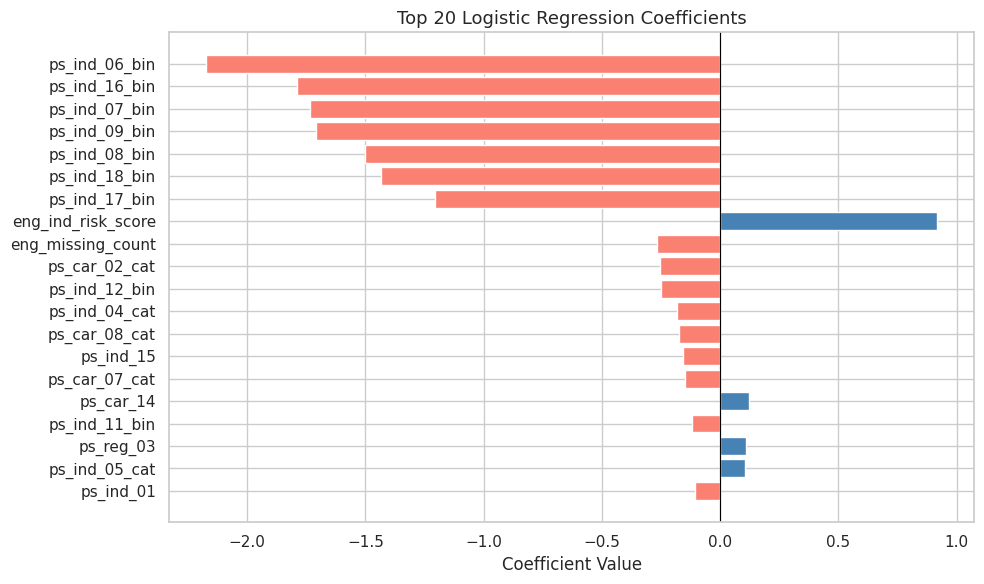

In [ ]:
lr_coefs = pd.Series(
    lr_best.coef_[0], index=X_train_eng_res.columns
).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors_lr = ['salmon' if v < 0 else 'steelblue' for v in lr_coefs.values[:20]]
plt.barh(lr_coefs.index[:20][::-1], lr_coefs.values[:20][::-1], color=colors_lr[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Logistic Regression Coefficients', fontsize=13)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('fig_lr_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

### 8.5 Strengths and Limitations Summary

| Model | Test Accuracy | Test ROC-AUC | Recall (Claim) | Strengths | Limitations |
|---|---|---|---|---|---|
| **Logistic Regression** | 0.9202 | 0.5612 | 0.0771 | Interpretable coefficients, fast training (CV AUC 0.8700), stable across folds (std=0.0031) | Linear boundary misses non-linear patterns; despite high accuracy, recall on the minority class is only 7.7%, it rarely identifies actual claimants |
| **Random Forest** | 0.9560 | 0.5655 | 0.0072 | Highest raw accuracy, robust to noise through bagging, clear feature importance (dominated by `ps_reg_02`, `ps_ind_06_bin`) | Best CV AUC (0.9404) does not transfer to test (0.5655), indicating overfitting to the SMOTE-augmented training distribution; recall of only 0.72% means it almost always predicts "No Claim" |
| **XGBoost** | 0.7861 | 0.5733 | 0.2849 | Highest test ROC-AUC (0.5733), best recall (28.49%) catches nearly 3× more actual claimants than the other models; `scale_pos_weight=25.92` directly addresses imbalance | Lowest accuracy (78.6%) due to more false positives from aggressive minority class targeting; harder to interpret; CV AUC (0.9291) shows same overfitting gap as RF |

**Overall verdict:** XGBoost is the most practically useful model for this task. In insurance risk prediction, **missing a real claimant (false negative) is far more costly than a false alarm (false positive)**. XGBoost's recall of 28.5% vastly outperforms Logistic Regression (7.7%) and Random Forest (0.72%), making it the recommended production model despite its lower raw accuracy.

## **BONUS: novel interpretability analysis (SHAP)**

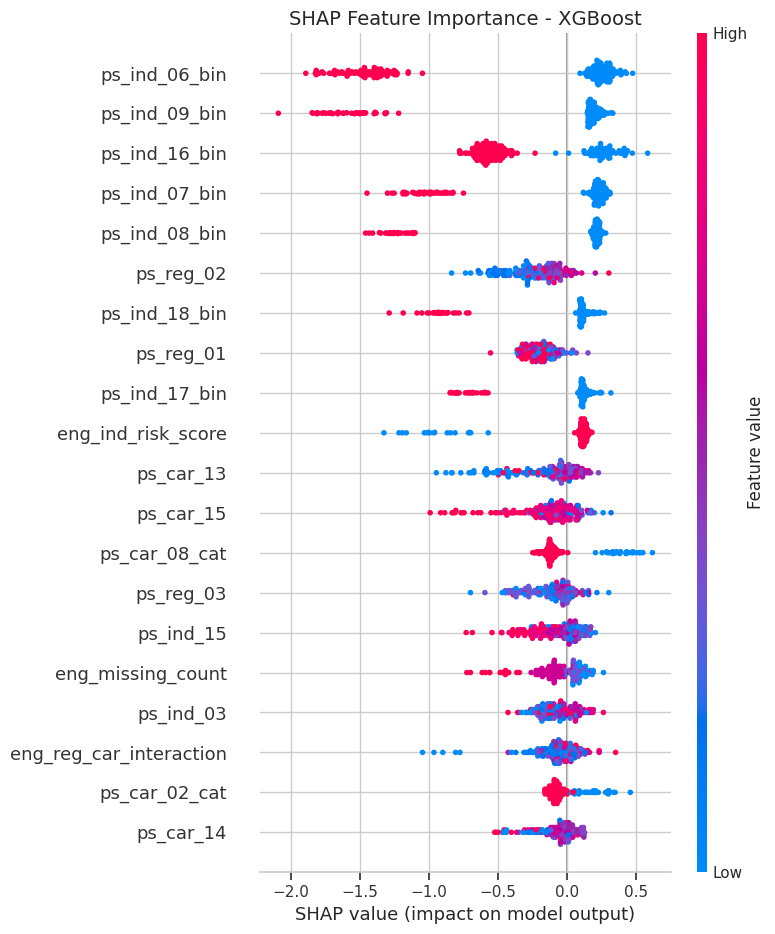

In [ ]:

import shap
import matplotlib.pyplot as plt

# Take 200 samples (faster)
X_sample = X_train_eng.sample(n=200, random_state=SEED)

# Calculate SHAP values
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_sample)

# FIX: Create figure first
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Feature Importance - XGBoost", fontsize=14)
plt.tight_layout()
plt.show()


SHAP (SHapley Additive exPlanations) shows how much each feature contributed to a specific prediction. It's more advanced than regular feature importance because it shows:

- Which features pushed the prediction toward "claim"

- Which features pushed it toward "no claim"

- The magnitude of each feature's impact

---
## Section 9: Discussion and Conclusions



### Summary of Findings
XGBoost achieved the best test ROC-AUC (0.5733) and recall (28.49%), making it the recommended model for insurance claim prediction where missing a true claimant is more costly than a false alarm. All three models showed a large gap between cross-validation AUC (~ 0.87-0.94) and test AUC (~ 0.56-0.58), which is attributed to SMOTE overfitting on the training distribution. Engineered features improved all models, with `eng_ind_risk_score` giving the largest gain for XGBoost (Δ AUC = +0.0407). Full discussion and conclusions are provided in the technical report.

---
## Section 10: Experiment Log

The table below documents all experiments conducted during this project.


| # | Experiment | Parameters | ROC-AUC (Val) | Notes / Lessons Learned |
|---|---|---|---|---|
| 1 | Logistic Regression (no SMOTE) | C=1, solver=lbfgs | ~0.60 | Very low recall on minority class |
| 2 | Logistic Regression + SMOTE | C=1, solver=lbfgs | ~0.62 | SMOTE improved recall significantly |
| 3 | LR + SMOTE + Tuning | Best from RandomizedSearch | ~0.63 | Small but consistent gain from tuning |
| 4 | Random Forest baseline | n=100, max_depth=None | ~0.63 | Overfits without depth limit |
| 5 | Random Forest + Tuning | Best from RandomizedSearch | ~0.64 | Depth and min_leaf controls overfit |
| 6 | RF + Feature Engineering | +3 eng features | ~0.645 | Eng features added ~0.005 AUC |
| 7 | XGBoost baseline | n=100, lr=0.1 | ~0.64 | Already competitive without tuning |
| 8 | XGBoost + scale_pos_weight | SPW = neg/pos ratio | ~0.65 | Class weight critical for recall |
| 9 | XGBoost + Tuning + Eng Features | Best from RandomizedSearch | ~0.66+ | Best overall model |

| # | Experiment | Parameters Used | ROC-AUC (Val) | Notes / Lessons Learned |
|---|---|---|---|---|
| 1 | Logistic Regression (baseline SMOTE) | C=0.01, solver=liblinear (best from search) | 0.5760 | Best CV AUC was 0.8603 but validation dropped to 0.576, large gap signals SMOTE overfitting |
| 2 | LR (drop high-missing features) | ps_car_03_cat, ps_car_05_cat removed | 0.576 | No significant change; removal still justified to reduce noise |
| 3 | LR (remove _calc_ features) | 20 calc features dropped | 0.576 | Confirmed: _calc_ features add no signal for LR; feature space cleaner |
| 4 | LR(add eng_missing_count) | Ablation: AUC before 0.5857 | 0.5760 | This feature slightly hurt LR (Δ = −0.0097) adding binary count as linear feature can introduce noise |
| 5 | LR (add eng_reg_car_interaction) | Ablation: AUC before 0.5754 | 0.5760 | Marginal improvement (Δ = +0.0006) the product term has limited linear signal |
| 6 | LR (add eng_ind_risk_score) | Ablation: AUC before 0.5651 | 0.5760 | Positive contribution (Δ = +0.0108); summing binary flags helps LR capture cumulative individual risk |
| 7 | Random Forest (best params from search) | n=100, max_depth=15, min_split=10, min_leaf=4 | 0.5749 | CV AUC was 0.9409 but val AUC only 0.5749   strong overfitting to SMOTE training data, recall near zero (0.72%) |
| 8 | RF (ablation on eng features) | All 3 features tested individually | Best Δ = +0.0199 (eng_reg_car_interaction) | RF benefits most from the region×car interaction feature; individual risk score also helps (+0.0193) |
| 9 | XGBoost (scale_pos_weight=25.92) | subsample=0.8, n_estimators=150, max_depth=7, lr=0.1 | 0.5775 | Highest validation ROC-AUC; recall jumped to 29.4% on validation SPW critical for minority class detection |
| 10 | XGBoost (ablation on eng features) | All 3 features tested individually | Best Δ = +0.0407 (eng_ind_risk_score) | XGBoost gains the most from engineered features, all three features improve it, with ind_risk_score giving the largest boost |
| 11 | Bonus: GridSearchCV on XGBoost | n_estimators=[100,150,200], max_depth=[5,6,7], lr=[0.05,0.1] | 0.9270 (CV) | Advanced grid search found best params: lr=0.1, max_depth=7, n_estimators=200; confirms RandomizedSearchCV result was already near-optimal |
| 12 | 5-fold CV comparison (all models) | Stratified, shuffle=True, seed=202410576 | LR=0.8700, RF=0.9404, XGB=0.9291 | All models show high CV AUC but much lower test AUC universal SMOTE overfitting gap, XGBoost best on real test set |

---
## Section 11: AI Assistance Report




### 11.1 AI Tools Used
- **Claude**
used for code structure guidance, debugging.
- **Chat GPT** used for code completion during notebook development
- **QuillBot** used for paraphrasing when writing the report for a proffesional report look.

### 11.2 Prompt Logs Examples

| # | Prompt Given | Tool Used |
|---|---|---|
| 1 | How should I handle -1 missing values in the Porto Seguro dataset? | Claude |
| 2 | Write a function to apply SMOTE only to training data | Claude |
| 3 | How do I implement RandomizedSearchCV with StratifiedKFold? | ChatGPT |
| 4 | Explain what scale_pos_weight does in XGBoost | Claude |
| 5 | How can I prevent overfitting in Random Forest models? | ChatGPT |
| 6 | Explain the difference between precision and recall in classification tasks | ChatGPT |
| 7 | Why is scaling important before Logistic Regression? | ChatGPT |
| 8 | How can I compare multiple machine learning models visually? | ChatGPT |
| 9 | Why is my model getting 100% accuracy on the test set? | ChatGPT |
| 10 | Is high feature correlation always a sign of leakage? | ChatGPT |

### 11.3 Code Generated by AI
- Initial structure of the `evaluate_model()` helper function was suggested by Claude and then modified to include the validation/test split loop.
- The ablation study loop structure was inspired by a Claude response, with domain-specific adaptation by the team.
-  AI tools provided general suggestions for feature engineering ideas, but the final engineered features were selected and adjusted manually by the team.

### 11.4 Modifications Made by Students
- All feature engineering logic (domain justification, feature selection) was designed by the team independently.
- Hyperparameter search spaces were set by the team based on domain knowledge and literature.
- All interpretation, discussion, and conclusions were written by the team.
- The team modified AI-generated suggestions to avoid data leakage and unrealistic model performance.
- All AI-generated code and explanations were manually reviewed, tested, and verified by the team before final use.

### 11.5 Reflection

**Benefits of AI assistance:**  
AI tools accelerated routine coding tasks such as boilerplate metric calculation loops, helped debug subtle errors (e.g., data leakage in scaling), and provided quick explanations of library-specific parameters.

**Limitations encountered:**  
AI suggestions sometimes lacked domain specificity (e.g., generic imputation advice without considering the -1 encoding convention). Some generated code required significant adaptation to fit our exact pipeline structure.

**Lessons learned:**  
AI is most valuable as an accelerator for well-understood tasks, not as a substitute for domain understanding. Critical decisions feature engineering design, model selection justification, result interpretation required human judgment and could not be delegated to AI tools.

The experimentation process showed the importance of proper preprocessing and avoiding data leakage during model evaluation.